# Анализ трех тикеров

df_transfap  - первый тикет

df_krasoctao - второй тикет

df_irkut3  - третий тикет

### Загрузка данных

In [63]:
import pandas as pd #библиотека для визуализации данных
from IPython.display import display #функция позволит явно вывести объект
import numpy as np 

df_transfap = pd.read_csv("transfap") #первый тикет
df_krasoctao = pd.read_csv("КрасОкт_ао") #второй тикет
df_irkut3 = pd.read_csv("ИРКУТ_3") #третий тикет

In [64]:
#посмотрим как выглядят данные
print("Первые десять строк в таблице:")
display(df_transfap.head())
display(df_krasoctao.head())
display(df_irkut3.head())

#посмотрим последнюю строчку
display(df_transfap.iloc[-1])

Первые десять строк в таблице:


,<TICKER>,<PER>,<DATE>,<TIME>,<CLOSE>,<VOL>
0,Транснф_ап,D,20081222,0,7536.84,2689
1,Транснф_ап,D,20081223,0,7748.00,6396
2,Транснф_ап,D,20081224,0,7576.93,4259
3,Транснф_ап,D,20081225,0,7350.00,4529
4,Транснф_ап,D,20081226,0,7011.11,2712


,<TICKER>,<PER>,<DATE>,<TIME>,<CLOSE>,<VOL>
0,КрасОкт-ао,D,20081222,0,213.0,142
1,КрасОкт-ао,D,20081223,0,200.0,136
2,КрасОкт-ао,D,20081224,0,190.0,121
3,КрасОкт-ао,D,20081225,0,175.0,420
4,КрасОкт-ао,D,20081226,0,175.0,15


,<TICKER>,<PER>,<DATE>,<TIME>,<CLOSE>,<VOL>
0,ИРКУТ-3,D,20081222,0,3.300,1500
1,ИРКУТ-3,D,20081223,0,3.410,28600
2,ИРКУТ-3,D,20081224,0,3.550,147900
3,ИРКУТ-3,D,20081225,0,3.400,97000
4,ИРКУТ-3,D,20081226,0,3.525,130500


<TICKER>    Транснф_ап
<PER>                D
<DATE>        20220719
<TIME>               0
<CLOSE>       112300.0
<VOL>             2009
Name: 4957, dtype: object

In [65]:
#удалим ненужные столбцы
df_transfap.drop(["<TICKER>", "<PER>", "<TIME>"], axis=1, inplace=True)
df_krasoctao.drop(["<TICKER>", "<PER>", "<TIME>"], axis=1, inplace=True)
df_irkut3.drop(["<TICKER>", "<PER>", "<TIME>"], axis=1, inplace=True)

In [66]:
#поменяем название оставшихся
df_transfap.rename(columns={"<DATE>": "Дата"}, inplace=True)
df_transfap.rename(columns={"<CLOSE>":"Цена"}, inplace=True)
df_transfap.rename(columns={"<VOL>":"Объем"}, inplace=True)

df_krasoctao.rename(columns={"<DATE>": "Дата"}, inplace=True)
df_krasoctao.rename(columns={"<CLOSE>":"Цена"}, inplace=True)
df_krasoctao.rename(columns={"<VOL>":"Объем"}, inplace=True)

df_irkut3.rename(columns={"<DATE>": "Дата"}, inplace=True)
df_irkut3.rename(columns={"<CLOSE>":"Цена"}, inplace=True)
df_irkut3.rename(columns={"<VOL>":"Объем"}, inplace=True)

In [67]:
df_transfap.head()

,Дата,Цена,Объем
0,20081222,7536.84,2689
1,20081223,7748.00,6396
2,20081224,7576.93,4259
3,20081225,7350.00,4529
4,20081226,7011.11,2712


In [68]:
#Поменяем формат столбца Дата
df_transfap["Дата"] = pd.to_datetime(df_transfap["Дата"], format='%Y%m%d')
df_krasoctao["Дата"] = pd.to_datetime(df_krasoctao["Дата"], format = '%Y%m%d')
df_irkut3["Дата"] = pd.to_datetime(df_irkut3["Дата"], format = '%Y%m%d')

### Предобработка данных

In [69]:
display(df_transfap.describe())
display(df_krasoctao.describe())
display(df_irkut3.describe())

,Дата,Цена,Объем
count,4958,4958.000000,4958.000000
mean,2015-10-05 12:00:00,110711.829322,5580.297701
min,2008-12-22 00:00:00,6122.960000,0.000000
25%,2012-05-14 06:00:00,53517.000000,0.000000
50%,2015-10-05 12:00:00,131805.000000,1612.500000
75%,2019-02-25 18:00:00,162600.000000,5552.250000
max,2022-07-19 00:00:00,231000.000000,182570.000000
std,NaN,58579.818604,11596.650253


,Дата,Цена,Объем
count,4958,4958.000000,4958.000000
mean,2015-10-05 12:00:00,290.013584,1385.917104
min,2008-12-22 00:00:00,85.000000,0.000000
25%,2012-05-14 06:00:00,180.005000,0.000000
50%,2015-10-05 12:00:00,305.120000,120.000000
75%,2019-02-25 18:00:00,366.000000,769.750000
max,2022-07-19 00:00:00,840.000000,289610.000000
std,NaN,122.603433,9027.927276


,Дата,Цена,Объем
count,4958,4958.000000,4.958000e+03
mean,2015-10-05 12:00:00,15.382586,1.532985e+05
min,2008-12-22 00:00:00,3.100000,0.000000e+00
25%,2012-05-14 06:00:00,6.330000,0.000000e+00
50%,2015-10-05 12:00:00,9.200000,4.230000e+04
75%,2019-02-25 18:00:00,24.320000,1.244250e+05
max,2022-07-19 00:00:00,77.150000,1.833340e+07
std,NaN,12.635164,6.235901e+05


In [70]:
#проверим совпадают ли даты у всех тикеров
are_equal = df_transfap['Дата'].equals(df_krasoctao['Дата']) and df_krasoctao['Дата'].equals(df_irkut3['Дата'])

if are_equal:
    print("Все даты во всех таблицах совпадают идеально.")
else:
    print("Есть расхождения в датах или длине таблиц.")

Все даты во всех таблицах совпадают идеально.


.reset_index(drop=True) - переписывает все индексы заново

In [71]:
#удалим строки, где объем = 0 (или пропущен)
bad_indices = set()

for df in [df_transfap, df_krasoctao, df_irkut3]:
    invalid_rows = df[(df['Цена'] <= 0) | (df['Объем'] <= 0) | 
                      (df['Цена'].isna()) | (df['Объем'].isna())].index
    bad_indices.update(invalid_rows)

df_transfap = df_transfap.drop(index=bad_indices).reset_index(drop=True)
df_krasoctao = df_krasoctao.drop(index=bad_indices).reset_index(drop=True)
df_irkut3 = df_irkut3.drop(index=bad_indices).reset_index(drop=True)

In [72]:
display(df_transfap.describe())
display(df_krasoctao.describe())
display(df_irkut3.describe())

,Дата,Цена,Объем
count,3048,3048.000000,3048.000000
mean,2015-11-14 14:11:20.314960,111503.288583,8588.936352
min,2008-12-22 00:00:00,6289.000000,21.000000
25%,2012-01-26 18:00:00,47887.500000,1459.750000
50%,2016-04-19 00:00:00,136875.000000,3151.500000
75%,2019-06-10 06:00:00,164275.000000,10291.000000
max,2022-07-19 00:00:00,231000.000000,182570.000000
std,NaN,60095.028104,13868.410013


,Дата,Цена,Объем
count,3048,3048.000000,3048.000000
mean,2015-11-14 14:11:20.314960,301.732815,2254.378937
min,2008-12-22 00:00:00,85.000000,1.000000
25%,2012-01-26 18:00:00,200.000000,179.500000
50%,2016-04-19 00:00:00,313.215000,540.000000
75%,2019-06-10 06:00:00,375.552500,1362.500000
max,2022-07-19 00:00:00,840.000000,289610.000000
std,NaN,123.064822,11429.572640


,Дата,Цена,Объем
count,3048,3048.000000,3.048000e+03
mean,2015-11-14 14:11:20.314960,16.420467,2.347178e+05
min,2008-12-22 00:00:00,3.100000,3.000000e+02
25%,2012-01-26 18:00:00,6.713500,4.250000e+04
50%,2016-04-19 00:00:00,9.700000,9.030000e+04
75%,2019-06-10 06:00:00,24.940000,1.966000e+05
max,2022-07-19 00:00:00,77.150000,1.833340e+07
std,NaN,13.021606,7.577929e+05


Было 4958 значений, после удаления стало 3048 значений. 

### Логдоходность

Для расчета дневной логарифмической доходности используем формулу:$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [73]:
#функция расчета логдоходности

def calc_logprofit(df):

    df["Ln"] = np.log(df["Цена"] / df["Цена"].shift(1))
    
    df = df.iloc[1:].reset_index(drop=True)

    return df

df_transfap = calc_logprofit(df_transfap)
df_krasoctao = calc_logprofit(df_krasoctao)
df_irkut3 = calc_logprofit(df_irkut3)

# Проверим результат 
display(df_transfap.head())
display(df_krasoctao.head())

,Дата,Цена,Объем,Ln
0,2008-12-23,7748.00,6396,0.027632
1,2008-12-24,7576.93,4259,-0.022327
2,2008-12-25,7350.00,4529,-0.030408
3,2008-12-26,7011.11,2712,-0.047204
4,2008-12-29,6830.00,2573,-0.026171


,Дата,Цена,Объем,Ln
0,2008-12-23,200.0,136,-0.062975
1,2008-12-24,190.0,121,-0.051293
2,2008-12-25,175.0,420,-0.082238
3,2008-12-26,175.0,15,0.000000
4,2008-12-29,180.0,32,0.028171


In [74]:
#количество строк, в которых хотя бы для одной компании логдоходность равна нулю:
print(len(df_transfap))
bad_indices = set()

for df in [df_transfap, df_krasoctao, df_irkut3]:
    invalid_rows = df[(df['Ln'] == 0)].index
    bad_indices.update(invalid_rows)

print(len(bad_indices))

df_transfap = df_transfap.drop(index=bad_indices).reset_index(drop=True)
df_krasoctao = df_krasoctao.drop(index=bad_indices).reset_index(drop=True)
df_irkut3 = df_irkut3.drop(index=bad_indices).reset_index(drop=True)

print(len(df_transfap))

3047
319
2728


### Первичный анализ

In [75]:
#выборочное среднее значение логдоходности (mean) и несмещённая оценку стандартного отклонения логдоходности (std)
display(df_transfap.describe())
display(df_krasoctao.describe())
display(df_irkut3.describe())


,Дата,Цена,Объем,Ln
count,2728,2728.000000,2728.000000,2728.000000
mean,2015-09-27 17:04:34.486803,109132.981910,8979.373167,0.000992
min,2008-12-23 00:00:00,6318.000000,21.000000,-0.325370
25%,2011-12-01 18:00:00,44586.250000,1513.750000,-0.010095
50%,2016-01-25 12:00:00,133980.000000,3469.500000,0.000379
75%,2019-05-14 12:00:00,163000.000000,11074.250000,0.010635
max,2022-07-19 00:00:00,231000.000000,182570.000000,0.199636
std,NaN,60369.899527,14115.709682,0.025425


,Дата,Цена,Объем,Ln
count,2728,2728.000000,2728.000000,2728.000000
mean,2015-09-27 17:04:34.486803,300.679575,2294.467742,-0.000044
min,2008-12-23 00:00:00,85.000000,1.000000,-0.509009
25%,2011-12-01 18:00:00,200.000000,190.000000,-0.015748
50%,2016-01-25 12:00:00,312.720000,560.000000,-0.002445
75%,2019-05-14 12:00:00,373.000000,1410.000000,0.012749
max,2022-07-19 00:00:00,840.000000,289610.000000,0.479729
std,NaN,122.314726,11591.767290,0.046526


,Дата,Цена,Объем,Ln
count,2728,2728.000000,2.728000e+03,2728.000000
mean,2015-09-27 17:04:34.486803,16.156598,2.419663e+05,0.000754
min,2008-12-23 00:00:00,3.100000,3.000000e+02,-0.322623
25%,2011-12-01 18:00:00,6.679750,4.317500e+04,-0.010993
50%,2016-01-25 12:00:00,9.480000,9.150000e+04,-0.001322
75%,2019-05-14 12:00:00,24.765000,2.008500e+05,0.010191
max,2022-07-19 00:00:00,77.150000,1.833340e+07,0.262364
std,NaN,12.913137,7.901671e+05,0.031882


In [76]:
#корреляция между столбцами Ln
corr_trans_kras = df_transfap['Ln'].corr(df_krasoctao['Ln'])
corr_trans_irkut = df_transfap['Ln'].corr(df_irkut3['Ln'])
corr_kras_irkut = df_krasoctao['Ln'].corr(df_irkut3['Ln'])

print(f"ρ(Транснф ап, КрасОкт-ао) = {corr_trans_kras:.12f}")
print(f"ρ(Транснф ап, ИРКУТ-3) = {corr_trans_irkut:.12f}")
print(f"ρ(КрасОкт-ао, ИРКУТ-3) = {corr_kras_irkut:.12f}")

ρ(Транснф ап, КрасОкт-ао) = 0.085477573094
ρ(Транснф ап, ИРКУТ-3) = 0.207393278009
ρ(КрасОкт-ао, ИРКУТ-3) = 0.139859857765


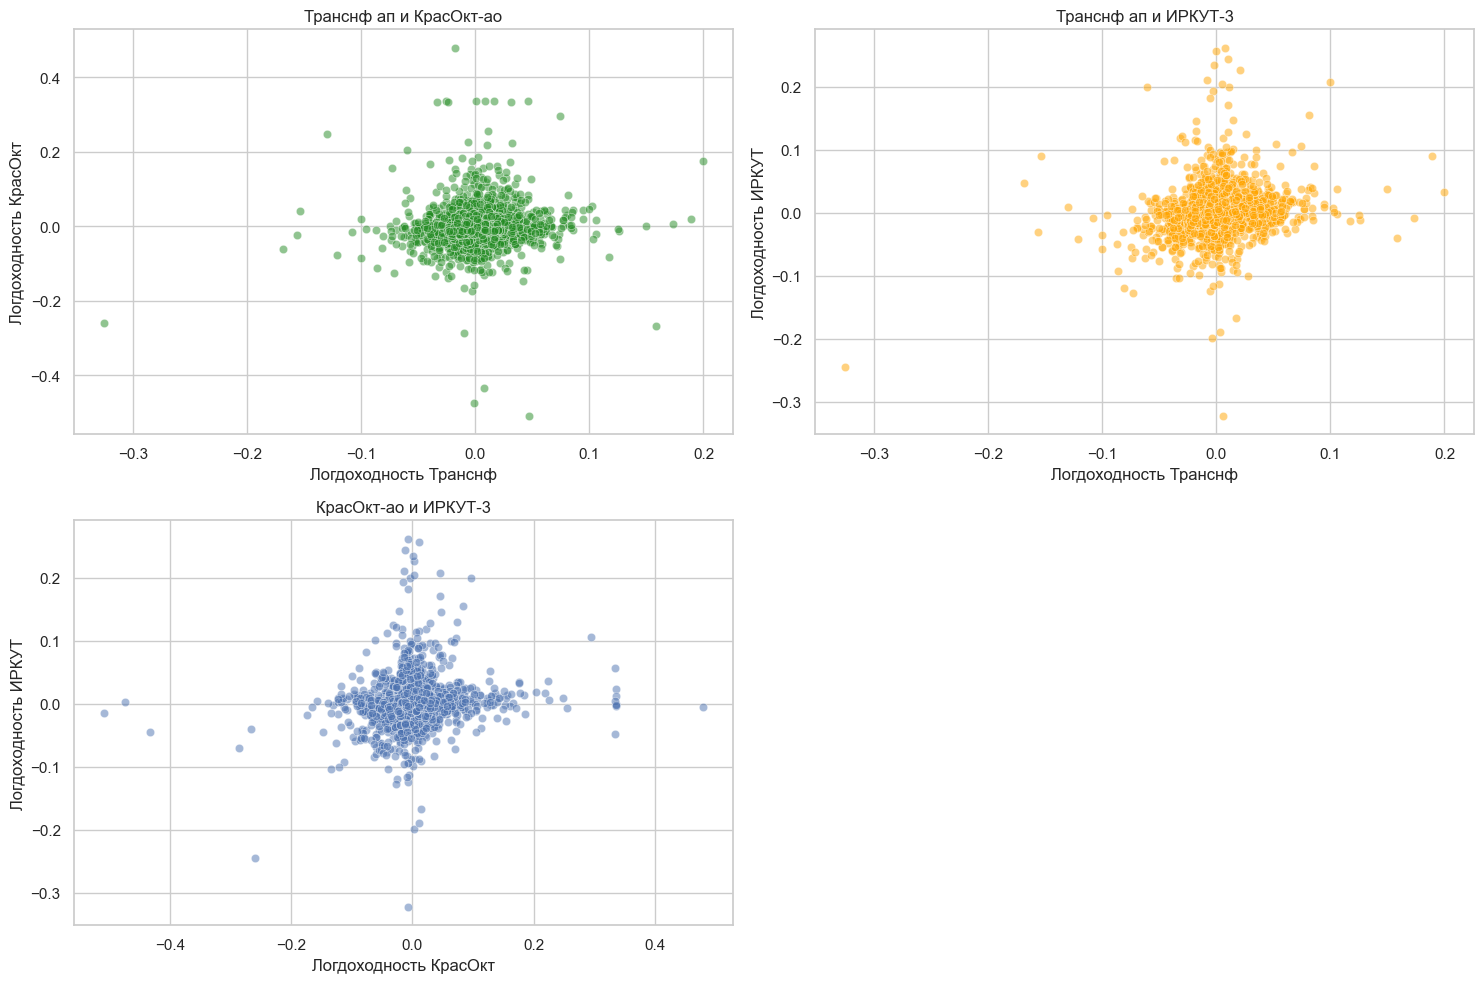

In [77]:
#Построим диаграммы рассивания 
import seaborn as sns
import matplotlib.pyplot as plt 

sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(15, 10))

# Диаграмма 1: Транснф vs КрасОкт
ax1 = fig.add_subplot(2, 2, 1)
sns.scatterplot(x=df_transfap['Ln'], y=df_krasoctao['Ln'], ax=ax1, color = 'forestgreen', alpha=0.5)
ax1.set_title('Транснф ап и КрасОкт-ао')
ax1.set_xlabel('Логдоходность Транснф')
ax1.set_ylabel('Логдоходность КрасОкт')

# Диаграмма 2: Транснф vs ИРКУТ
ax2 = fig.add_subplot(2, 2, 2)
sns.scatterplot(x=df_transfap['Ln'], y=df_irkut3['Ln'], ax=ax2, color='orange', alpha=0.5)
ax2.set_title('Транснф ап и ИРКУТ-3')
ax2.set_xlabel('Логдоходность Транснф')
ax2.set_ylabel('Логдоходность ИРКУТ')

# Диаграмма 3: КрасОкт vs ИРКУТ
ax3 = fig.add_subplot(2, 2, 3)
sns.scatterplot(x=df_krasoctao['Ln'], y=df_irkut3['Ln'], ax=ax3, alpha=0.5)
ax3.set_title('КрасОкт-ао и ИРКУТ-3')
ax3.set_xlabel('Логдоходность КрасОкт')
ax3.set_ylabel('Логдоходность ИРКУТ')

plt.tight_layout()
plt.show()

Исходя из посчитаной корелляции и диаграмм рассесивания линейной зависимости нет. 

In [78]:
#проверим выборочное среднее значение увеличив количество знаков
print(f"Среднее КрасОкт-ао: {df_krasoctao['Ln'].mean():.12f}")
print(f"Среднее ИРКУТ-3:    {df_irkut3['Ln'].mean():.12f}")

Среднее КрасОкт-ао: -0.000043775269
Среднее ИРКУТ-3:    0.000753523048


In [79]:
import matplotlib.pyplot as plt #библиотека для визуализации данных

**заметки**

plt.scatter(x, y, цвет точки, размер точки, edgecolors (обводка)) - создает график рассеивания, условно добавляет точки на график  
plt.annotate(текст надписи, (x, y), xytext=(x1, y1) расположение текста, textcoords='offset points' - где задается координата) - добавляет надписи
sns.boxplot(data=box_data, orient, ax, palette) - построение бочки с усами 

Результаты расчетов:
       Ticker      Mean       Std  Optimal
0  Транснф ап  0.000992  0.025425        1
1  КрасОкт-ао -0.000044  0.046526        0
2     ИРКУТ-3  0.000754  0.031882        0



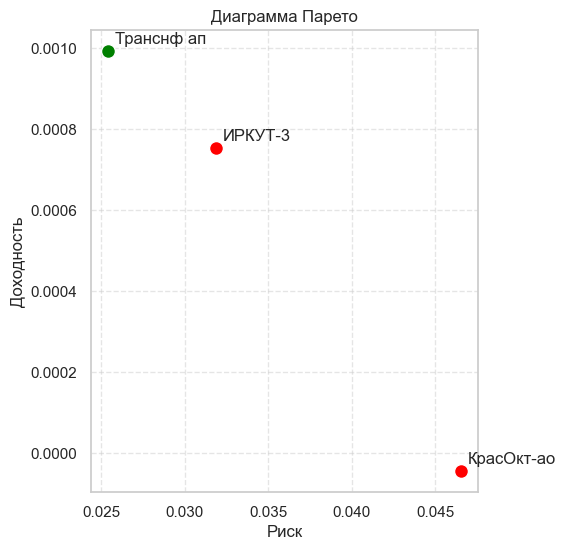

In [80]:
#Диаграма Парето (риск-доходность)

data = {
    'Ticker': ['Транснф ап', 'КрасОкт-ао', 'ИРКУТ-3'],
    'Mean': [df_transfap['Ln'].mean(), df_krasoctao['Ln'].mean(), df_irkut3['Ln'].mean()],
    'Std': [df_transfap['Ln'].std(), df_krasoctao['Ln'].std(), df_irkut3['Ln'].std()]
}
res = pd.DataFrame(data)

#Определим оптимальный тикер по Парето

optimal_flags = []

for i, row in res.iterrows():

    is_optimal = True

    for j, other in res.iterrows():

        if i == j: continue

        better_risk = other['Std'] <= row['Std'] and other['Mean'] >= row['Mean'] #Риск меньше или равен и Доходность больше или равна 
        
        if better_risk:
            is_optimal = False #значит какой-либо other доминирует над row => row уже не оптимален
            break

    optimal_flags.append(1 if is_optimal else 0)

res['Optimal'] = optimal_flags

print(f"Результаты расчетов:\n{res}\n")


#построение графика
plt.figure(figsize=(5, 6))

for i, row in res.iterrows():
    color = 'green' if row['Optimal'] == 1 else 'red'
    plt.scatter(row['Std'], row['Mean'], c=color, s=100, edgecolors='white')
    plt.annotate(row['Ticker'], (row['Std'], row['Mean']), xytext=(5, 5), textcoords='offset points')

plt.title('Диаграмма Парето')
plt.xlabel('Риск')
plt.ylabel('Доходность')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

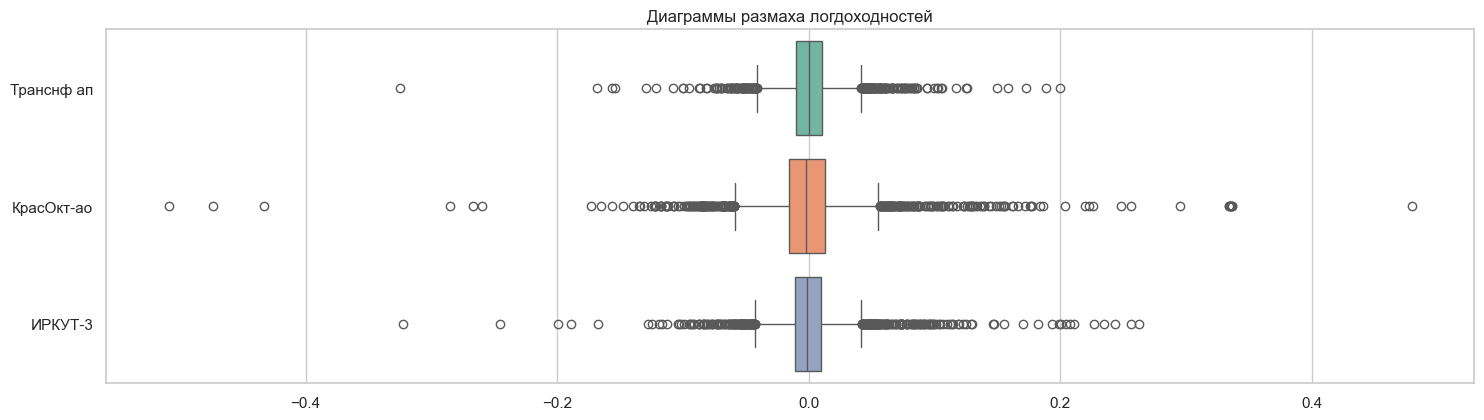

In [81]:
#Диаграмма размаха логарифмической доходности 
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(15, 12))

ax5 = fig.add_subplot(3, 1, 3)
box_data = pd.DataFrame({
    'Транснф ап': df_transfap['Ln'], 
    'КрасОкт-ао': df_krasoctao['Ln'],
    'ИРКУТ-3': df_irkut3['Ln']
})

sns.boxplot(data=box_data, orient='h', ax=ax5, palette="Set2")
ax5.set_title('Диаграммы размаха логдоходностей')

plt.tight_layout()
plt.show()

In [82]:
#посчитаем Эксцесс и Модуль коэффициента асимметрии
kurt_before1 = df_transfap["Ln"].kurt()
skew_before1 = df_transfap["Ln"].skew()
abs_skew_before1 = abs(skew_before1)

kurt_before2 = df_krasoctao["Ln"].kurt()
skew_before2 = df_krasoctao["Ln"].skew()
abs_skew_before2 = abs(skew_before2)

kurt_before3 = df_irkut3["Ln"].kurt()
skew_before3 = df_irkut3["Ln"].skew()
abs_skew_before3 = abs(skew_before3)

Исходя из графика видно наличие выбросов в выборке, расчитаем границы нормы для очистки данных

In [90]:
#Находим границы и очищаем отдельно каждую таблицу от выбросов

cleaned_dfs = {}
tables = {
    'Транснф': df_transfap, 
    'КрасОкт': df_krasoctao, 
    'ИРКУТ': df_irkut3
}

for name, df in tables.items():

    q1 = df['Ln'].quantile(0.25)
    q3 = df['Ln'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    df_clean = df[df['Ln'].between(lower, upper)].copy()
    cleaned_dfs[name] = df_clean
    
    n = len(df_clean)
    r = df_clean['Ln'].max() - df_clean['Ln'].min() #размах
    mean = df_clean['Ln'].mean()
    
    print(f"{name}: n = {n}, Размах = {r:.12f}")


    median = df_clean['Ln'].median()
    std = df_clean['Ln'].std()

    #посчитаем Эксцесс и Модуль коэффициента асимметрии после очистки
    kurt_after = df_clean['Ln'].kurt()
    skew_after = df_clean['Ln'].skew()
    abs_skew_after = abs(skew_after)

    print(f"Медиана: {median:.12f}")
    print(f"Среднее значение: {mean:.12f}")
    print(f"СКО (исправленное):      {std:.12f}")
    print(f"Эксцесс:                 {kurt_after:.12f}")
    print(f"Коэффициент асимметрии:  {skew_after:.12f}")
    print(f"Модуль коэффициента асимметрии:  {abs_skew_after:.12f}")

    print()
    print("Данные ДО")
    if name == "Транснф":

        print(f"Эксцесс:                 {kurt_before1:.12f}")
        print(f"Коэффициент асимметрии:  {skew_before1:.12f}")
        print(f"Модуль коэффициента асимметрии:  {abs_skew_before1:.12f}")

        df_transfap = df_clean

    elif name == "КрасОкт":

        print(f"Эксцесс:                 {kurt_before2:.12f}")
        print(f"Коэффициент асимметрии:  {skew_before2:.12f}")
        print(f"Модуль коэффициента асимметрии:  {abs_skew_before2:.12f}")

        df_krasoctao = df_clean
    
    else:

        print(f"Эксцесс:                 {kurt_before3:.12f}")
        print(f"Коэффициент асимметрии:  {skew_before3:.12f}")
        print(f"Модуль коэффициента асимметрии:  {abs_skew_before3:.12f}")

        df_irkut3 = df_clean
    
    print()
    print()


Транснф: n = 2520, Размах = 0.082751537050
Медиана: 0.000027284387
Среднее значение: 0.000071799341
СКО (исправленное):      0.015785249050
Эксцесс:                 0.074793688743
Коэффициент асимметрии:  -0.001752416775
Модуль коэффициента асимметрии:  0.001752416775

Данные ДО
Эксцесс:                 17.562765918936
Коэффициент асимметрии:  -0.243523077208
Модуль коэффициента асимметрии:  0.243523077208


КрасОкт: n = 2446, Размах = 0.113566134852
Медиана: -0.002560820862
Среднее значение: -0.001908803246
СКО (исправленное):      0.021200177488
Эксцесс:                 0.188807093602
Коэффициент асимметрии:  0.024631855809
Модуль коэффициента асимметрии:  0.024631855809

Данные ДО
Эксцесс:                 27.026657374421
Коэффициент асимметрии:  0.699738761936
Модуль коэффициента асимметрии:  0.699738761936


ИРКУТ: n = 2458, Размах = 0.084380448584
Медиана: -0.001602565474
Среднее значение: -0.000996499983
СКО (исправленное):      0.015724664596
Эксцесс:                 0.195962581

ДИ для математического ожидания (среднего): Строится с использованием $t$-распределения Стьюдента, так как истинная дисперсия генеральной совокупности нам неизвестна.Формула:$$\bar{x} - t_{1-\alpha/2, n-1} \frac{s}{\sqrt{n}} \le \mu \le \bar{x} + t_{1-\alpha/2, n-1} \frac{s}{\sqrt{n}}$$

ДИ для дисперсии: Строится с использованием распределения $\chi^2$ (Хи-квадрат). Оно несимметрично, поэтому для нижней и верхней границы используются разные критические значения.Формула:$$\frac{(n-1)s^2}{\chi^2_{1-\alpha/2, n-1}} \le \sigma^2 \le \frac{(n-1)s^2}{\chi^2_{\alpha/2, n-1}}$$

In [88]:
import scipy.stats as stats 

In [96]:
confidence = 0.95
alpha = 1 - confidence

tables = {
    'Транснф': df_transfap, 
    'КрасОкт': df_krasoctao, 
    'ИРКУТ': df_irkut3
}

for name, df in tables.items():
    n = len(df)
    mean = df['Ln'].mean()
    var = df['Ln'].var()
    std = df['Ln'].std()

    dof = n - 1 #степени свободы

    #доверительные интервалы для математического ожидания 
    t = stats.t.ppf(1 - alpha/2, dof)
    margin_of_error = t * (std / np.sqrt(n))

    mean_lower = mean - margin_of_error
    mean_upper = mean + margin_of_error

    print(f"ДИ для мат. ожидания {name}: [{mean_lower:.12f}; {mean_upper:.12f}]")

    #доверительные интервалы для дисперсии

    xi2_lower = stats.chi2.ppf(1 - alpha/2, dof) 
    xi2_upper = stats.chi2.ppf(alpha/2, dof)
    
    var_lower = (dof * var) / xi2_lower
    var_upper = (dof * var) / xi2_upper

    print(f"ДИ для дисперсии {name}: [{var_lower:.12f}; {var_upper:.12f}]")

    print()
    print()


ДИ для мат. ожидания Транснф: [-0.000544806996; 0.000688405677]
ДИ для дисперсии Транснф: [0.000235965940; 0.000263528729]


ДИ для мат. ожидания КрасОкт: [-0.002749374250; -0.001068232242]
ДИ для дисперсии КрасОкт: [0.000425280172; 0.000475745528]


ДИ для мат. ожидания ИРКУТ: [-0.001618445777; -0.000374554190]
ДИ для дисперсии ИРКУТ: [0.000234000503; 0.000261696102]




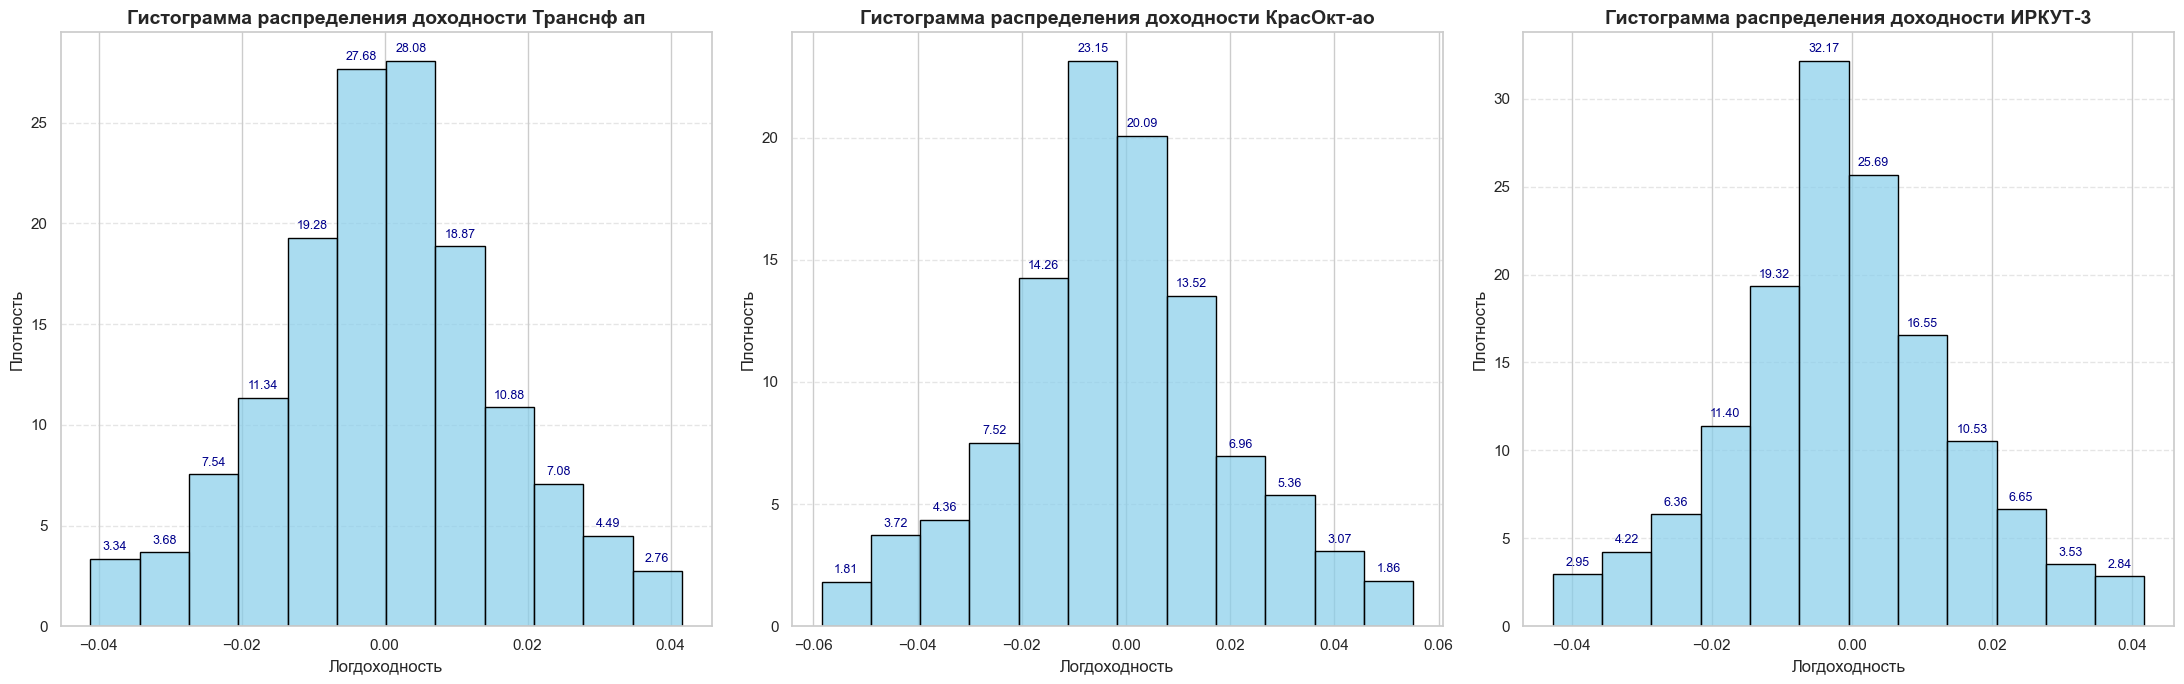

In [107]:
sns.set_theme(style="whitegrid")

raw_tables = {
    'Транснф ап': df_transfap['Ln'], 
    'КрасОкт-ао': df_krasoctao['Ln'],
    'ИРКУТ-3': df_irkut3['Ln']
}

fig, axes = plt.subplots(1, 3, figsize=(22, 7)) 

for (name, data), ax in zip(raw_tables.items(), axes):

    #Расчет оптимального количества интервалов
    n = len(data)
    num_bins = int(1 + np.log2(n)) if n > 0 else 10 #формула Стерджеса
    
    sns.histplot(data, bins=num_bins, stat='density', color='skyblue', alpha=0.7, ax=ax, edgecolor='black')
    
    for patch in ax.patches:
        height = patch.get_height()
        width = patch.get_width()
        x = patch.get_x()
        
        if height > (ax.get_ylim()[1] * 0.05): 
            ax.annotate(f'{height:.2f}', xy=(x + width/2, height), xytext=(0, 4), 
                        textcoords='offset points', ha='center', va='bottom', fontsize=9, color='darkblue')


    ax.set_title(f'Гистограмма распределения доходности {name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Логдоходность')
    ax.set_ylabel('Плотность')

        
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 7. АВТОМАТИЧЕСКОЕ ВЫРАВНИВАНИЕ И ВЫВОД
plt.tight_layout()
plt.show()